c:\Users\Ethan Z\miniconda3\envs\myenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\Ethan Z\miniconda3\envs\myenv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Ethan Z\miniconda3\envs\myenv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_re

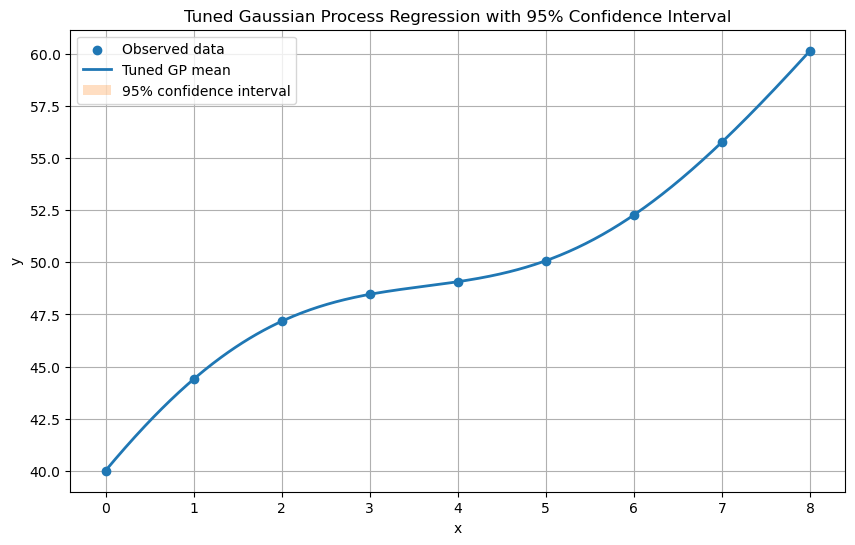

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load the dataset
# -----------------------------
file_path = Path("HW9.xlsx")
df = pd.read_excel(file_path)

X = df["x"].to_numpy().reshape(-1, 1)
y = df["y"].to_numpy()

# -----------------------------
# 2. Scale x-values
# -----------------------------
# Scaling x improves numerical conditioning for kernel optimization.
# This is especially helpful when using gradient-based optimization in GPR.
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Create a dense prediction grid in the ORIGINAL x-space, then scale it
# using the same transformation before passing it into the GP model.
X_dense = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
X_dense_scaled = x_scaler.transform(X_dense)

# -----------------------------
# 3. Define an RBF-based kernel
# -----------------------------
# ConstantKernel controls the vertical signal scale.
# RBF controls smoothness and correlation over distance in x.
# WhiteKernel lets the model estimate observation noise from the data,
# rather than forcing us to choose an arbitrary alpha value by hand.
kernel = (
  C(1.0, (1e-3, 1e3))
  * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
  + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e1))
)

# -----------------------------
# 4. Fit the tuned GP model
# -----------------------------
# n_restarts_optimizer helps avoid poor local optima by retrying the
# hyperparameter optimization from multiple starting points.
gpr = GaussianProcessRegressor(
  kernel=kernel,
  normalize_y=True,
  n_restarts_optimizer=50,
  random_state=42
)

gpr.fit(X_scaled, y)

# -----------------------------
# 5. Predict mean and uncertainty
# -----------------------------
# return_std=True gives the posterior standard deviation at each point.
# The 95% confidence band is approximated as mean ± 1.96 * std.
y_mean, y_std = gpr.predict(X_dense_scaled, return_std=True)
y_lower = y_mean - 1.96 * y_std
y_upper = y_mean + 1.96 * y_std

# -----------------------------
# 6. Leave-one-out validation
# -----------------------------
# This checks whether the tuned model still predicts well when each point
# is hidden once. It is a useful sanity check for whether the confidence
# interval is "earned" by the data or just an artifact of bad settings.
loo = LeaveOneOut()
loo_preds = []
loo_stds = []
loo_true = []

for train_idx, test_idx in loo.split(X_scaled):
  X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
  y_train, y_test = y[train_idx], y[test_idx]

  loo_model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
  )
  loo_model.fit(X_train, y_train)

  pred_mean, pred_std = loo_model.predict(X_test, return_std=True)

  loo_preds.append(pred_mean[0])
  loo_stds.append(pred_std[0])
  loo_true.append(y_test[0])

loo_preds = np.array(loo_preds)
loo_stds = np.array(loo_stds)
loo_true = np.array(loo_true)

loo_rmse = np.sqrt(mean_squared_error(loo_true, loo_preds))

# -----------------------------
# 7. Plot the tuned GP
# -----------------------------
plt.figure(figsize=(10, 6))

plt.scatter(X.ravel(), y, zorder=3, label="Observed data")
plt.plot(X_dense.ravel(), y_mean, linewidth=2, label="Tuned GP mean")
plt.fill_between(
  X_dense.ravel(),
  y_lower,
  y_upper,
  alpha=0.25,
  label="95% confidence interval"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Tuned Gaussian Process Regression with 95% Confidence Interval")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# -----------------------------
# 8. Print model diagnostics
# -----------------------------
print("Learned kernel:")
print(gpr.kernel_)
print()
print(f"Log marginal likelihood: {gpr.log_marginal_likelihood(gpr.kernel_.theta):.6f}")
print(f"Leave-one-out RMSE: {loo_rmse:.6f}")

: 

**c** The 95% confidence interval here is super duper tight, mostly because we have 9 data points and it's very hard to know the underlying shape, so the hyperparameters are kinda hard to tune. Therefore, it's easy to just assume minimal noise, as there's not much room for there to have nonlinear noise

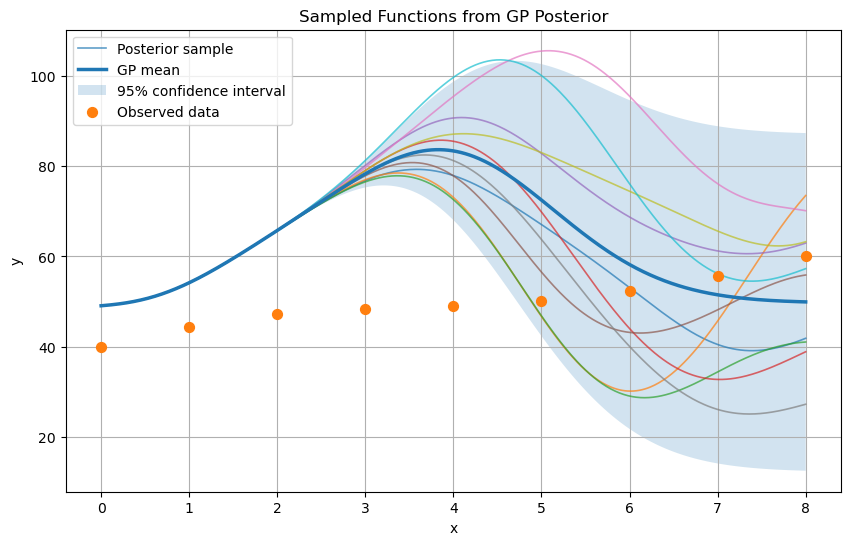

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Draw 10 sample functions from the GP posterior
y_samples = gpr.sample_y(X_dense, n_samples=10, random_state=42)

# Fix shape if needed (sklearn sometimes returns 3D)
if y_samples.ndim == 3:
  y_samples = y_samples[:, 0, :]

# Get mean + std for reference
y_mean, y_std = gpr.predict(X_dense, return_std=True)

y_lower = y_mean - 1.96 * y_std
y_upper = y_mean + 1.96 * y_std

# Plot everything
plt.figure(figsize=(10, 6))

for i in range(y_samples.shape[1]):
  plt.plot(
    X_dense.ravel(),
    y_samples[:, i],
    linewidth=1.2,
    alpha=0.7,
    label="Posterior sample" if i == 0 else None
  )

plt.plot(
  X_dense.ravel(),
  y_mean,
  linewidth=2.5,
  label="GP mean"
)

plt.fill_between(
  X_dense.ravel(),
  y_lower,
  y_upper,
  alpha=0.2,
  label="95% confidence interval"
)

plt.scatter(X.ravel(), y, s=50, zorder=3, label="Observed data")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Sampled Functions from GP Posterior")
plt.grid(True)
plt.legend()
plt.show()

**d.**
Each curve is sampled from the posterior, they represent the behaviour of the points, with dips in similar places. The curves look similar in the beginning, and diverge as the confidence lower.

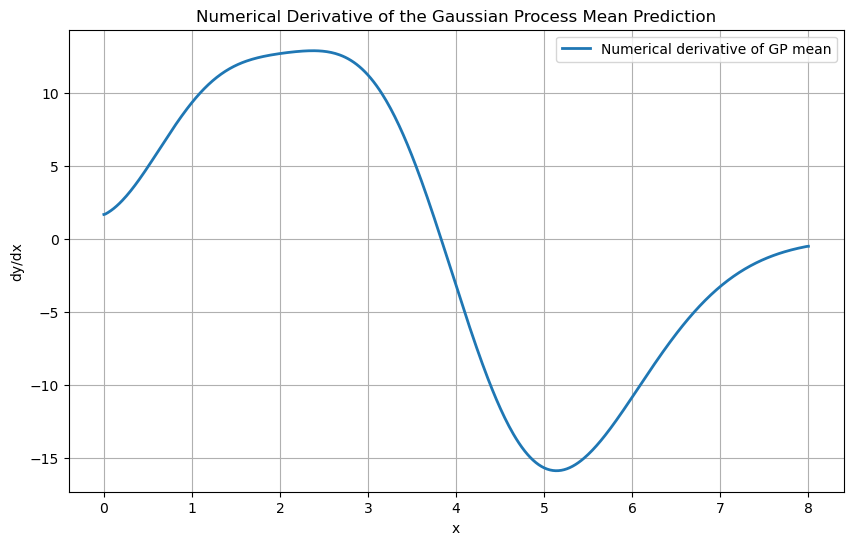

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the x-values as a 1D array for differentiation.
x_dense_1d = X_dense.ravel()

# Compute the numerical derivative of the GP mean prediction.
# This approximates dy/dx using neighboring points on the dense grid.
dy_dx = np.gradient(y_mean, x_dense_1d)

# Plot the derivative as a function of x.
plt.figure(figsize=(10, 6))
plt.plot(x_dense_1d, dy_dx, linewidth=2, label="Numerical derivative of GP mean")

# Add axis labels and formatting.
plt.xlabel("x")
plt.ylabel("dy/dx")
plt.title("Numerical Derivative of the Gaussian Process Mean Prediction")
plt.grid(True)
plt.legend()
plt.show()

**e.**
Smoothness was enforced on the plot. The numerical differentiation method uses second-order central differences, as the `numpy.gradient()` documentation says. Numerical differentiation is performed on the dense grid, because we only know the function values at those points with full confidence.

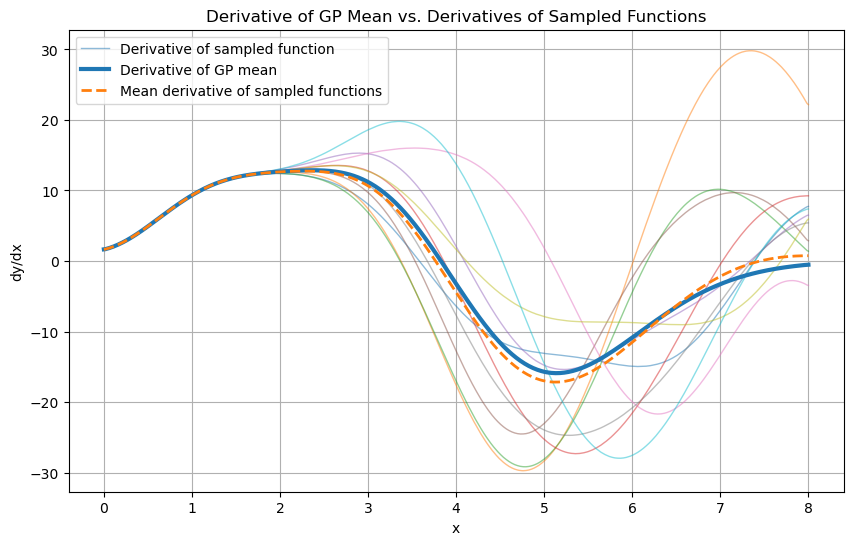

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure x is a 1D array for numerical differentiation.
x_dense_1d = X_dense.ravel()

# Compute the derivative of the GP mean prediction.
dy_dx_mean = np.gradient(y_mean, x_dense_1d)

# Draw posterior sample functions from the GP model.
# Using more than 10 samples makes the average sampled derivative more stable.
y_samples = gpr.sample_y(X_dense, n_samples=100, random_state=42)

# Handle sklearn shape differences if needed.
if y_samples.ndim == 3:
  y_samples = y_samples[:, 0, :]

# Compute the numerical derivative of each sampled function.
# Each column of dy_dx_samples corresponds to one sampled function derivative.
dy_dx_samples = np.column_stack([
  np.gradient(y_samples[:, i], x_dense_1d)
  for i in range(y_samples.shape[1])
])

# Compute the mean derivative across all sampled functions.
dy_dx_sample_mean = np.mean(dy_dx_samples, axis=1)

# Plot a subset of sampled derivatives so the figure stays readable.
plt.figure(figsize=(10, 6))

for i in range(10):
  plt.plot(
    x_dense_1d,
    dy_dx_samples[:, i],
    alpha=0.5,
    linewidth=1.0,
    label="Derivative of sampled function" if i == 0 else None
  )

# Plot the derivative of the GP mean prediction.
plt.plot(
  x_dense_1d,
  dy_dx_mean,
  linewidth=3,
  label="Derivative of GP mean"
)

# Plot the mean derivative of the sampled functions.
plt.plot(
  x_dense_1d,
  dy_dx_sample_mean,
  linewidth=2,
  linestyle="--",
  label="Mean derivative of sampled functions"
)

plt.xlabel("x")
plt.ylabel("dy/dx")
plt.title("Derivative of GP Mean vs. Derivatives of Sampled Functions")
plt.grid(True)
plt.legend()
plt.show()

# Quantify the difference between the two mean-like curves.
rmse_derivative = np.sqrt(np.mean((dy_dx_mean - dy_dx_sample_mean)**2))

**f.**
Yes, it should represent the mean of all the derivatives, you're just reducing the computation complexity by merging the functions before then differentiating. Unless the derivatives are critical, this method works a lot better for computation power, GPR is already slow enough. Sampling the posterior then differentiating is only useful if the derivative is extremely critical.

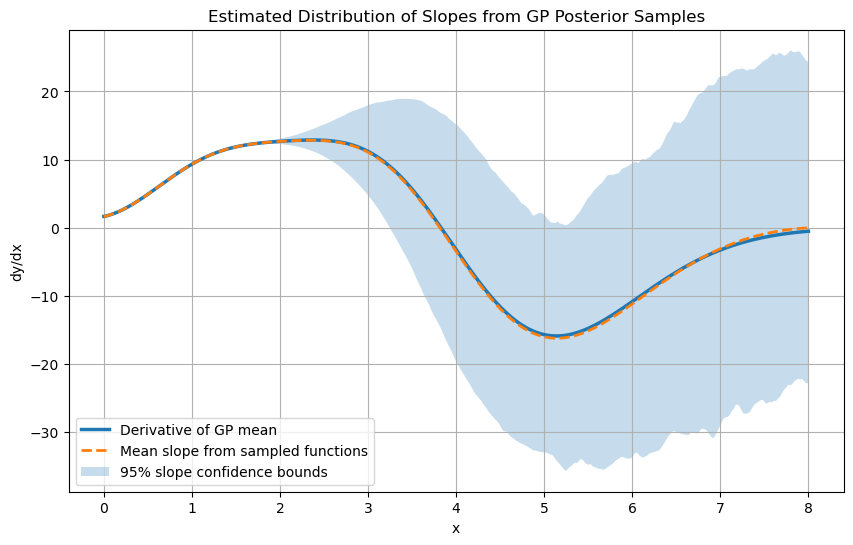

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. Set up x-grid and derivative of GP mean
# ----------------------------------------
x_dense_1d = X_dense.ravel()

# Derivative of the GP mean prediction from part 2(e)
dy_dx_mean = np.gradient(y_mean, x_dense_1d)

# ----------------------------------------
# 2. Sample many functions from the GP posterior
# ----------------------------------------
# Using many samples gives a more stable estimate of the slope distribution.
n_slope_samples = 500
y_samples = gpr.sample_y(X_dense, n_samples=n_slope_samples, random_state=42)

# Handle sklearn shape differences if needed.
if y_samples.ndim == 3:
  y_samples = y_samples[:, 0, :]

# ----------------------------------------
# 3. Differentiate each sampled function
# ----------------------------------------
# Each column in dy_dx_samples is the derivative of one sampled function.
dy_dx_samples = np.column_stack([
  np.gradient(y_samples[:, i], x_dense_1d)
  for i in range(y_samples.shape[1])
])

# ----------------------------------------
# 4. Build the slope distribution at each x
# ----------------------------------------
# Mean slope across posterior samples
dy_dx_sample_mean = np.mean(dy_dx_samples, axis=1)

# Pointwise 95% slope bounds from the sampled derivative distribution
dy_dx_lower = np.percentile(dy_dx_samples, 2.5, axis=1)
dy_dx_upper = np.percentile(dy_dx_samples, 97.5, axis=1)

# Optional: posterior standard deviation of slope
dy_dx_sample_std = np.std(dy_dx_samples, axis=1)

# ----------------------------------------
# 5. Plot the slope distribution
# ----------------------------------------
plt.figure(figsize=(10, 6))

# Plot the derivative of the GP mean
plt.plot(
  x_dense_1d,
  dy_dx_mean,
  linewidth=2.5,
  label="Derivative of GP mean"
)

# Plot the mean slope from sampled functions
plt.plot(
  x_dense_1d,
  dy_dx_sample_mean,
  linestyle="--",
  linewidth=2,
  label="Mean slope from sampled functions"
)

# Plot 95% confidence bounds for the slope distribution
plt.fill_between(
  x_dense_1d,
  dy_dx_lower,
  dy_dx_upper,
  alpha=0.25,
  label="95% slope confidence bounds"
)

plt.xlabel("x")
plt.ylabel("dy/dx")
plt.title("Estimated Distribution of Slopes from GP Posterior Samples")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------------------
# 6. Quantify agreement between the two slope means
# ----------------------------------------
rmse_slope = np.sqrt(np.mean((dy_dx_mean - dy_dx_sample_mean)**2))
max_abs_diff = np.max(np.abs(dy_dx_mean - dy_dx_sample_mean))

**g.** 
The distribution of slopes was estimated by sampling many functions from the Gaussian Process posterior and computing the numerical derivative of each sampled function, then average them out at each point to form the mean.

The mean slope at each point was obtained by averaging the derivatives across all sampled functions, while the 95% confidence bounds were estimated using the 2.5th and 97.5th percentiles of the sampled slopes.

The derivative of the GP mean prediction is very close to the mean slope of the sampled functions.

**h.**
Couple the slope with the x values and sort by their derivative. The information tells you where "hills" are to climb, to exploit the model.